# Experiment 4: K-Nearest Neighbors (KNN) Classification

**Objective**: Implement the K-Nearest Neighbors algorithm for classification and evaluate its performance using the Iris dataset.

**Dataset**: Iris dataset containing measurements of sepal and petal dimensions for three species of iris flowers.

## 1. Import Libraries

In [12]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')
# To compare clean vs polluted, load clean_df as:
# clean_df = pd.read_csv('archive (1)/Iris_clean_backup.csv')

All libraries imported successfully!


## 2. Data Loading and Exploration

In [13]:
# Load the polluted Iris dataset
# NOTE: Path has a space and matches the actual file location
import pandas as pd

df = pd.read_csv('archive (1)/Iris_polluted.csv')
print('Polluted dataset loaded successfully!')
print(f'Dataset shape: {df.shape}')

Polluted dataset loaded successfully!
Dataset shape: (162, 6)


In [14]:
# Dataset information
print('Dataset Information:')
print('='*50)
df.info()

print('\n' + '='*50)
print('Statistical Summary:')
print('='*50)
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             162 non-null    int64  
 1   SepalLengthCm  151 non-null    float64
 2   SepalWidthCm   144 non-null    float64
 3   PetalLengthCm  145 non-null    float64
 4   PetalWidthCm   149 non-null    float64
 5   Species        162 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.7 KB

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,162.000000,151.000000,144.000000,145.000000,149.000000
mean,81.500000,6.215365,3.208219,4.003825,1.293211
std,46.909487,1.627290,0.754644,2.127096,0.882948
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,41.250000,5.213437,2.800000,1.600000,0.300000
50%,81.500000,5.900000,3.047592,4.400000,1.400000
75%,121.750000,6.668611,3.400000,5.200000,1.900000
max,162.000000,14.036256,6.684453,12.399170,3.963363


In [15]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

print('\n' + '='*50)
print('Species Distribution:')
print('='*50)
print(df['Species'].value_counts())
print('\nPercentage:')
print(df['Species'].value_counts(normalize=True) * 100)

Missing Values:
Id                0
SepalLengthCm    11
SepalWidthCm     18
PetalLengthCm    17
PetalWidthCm     13
Species           0
dtype: int64

Species Distribution:
Species
Iris-versicolor    60
Iris-virginica     51
Iris-setosa        51
Name: count, dtype: int64

Percentage:
Species
Iris-versicolor    37.037037
Iris-virginica     31.481481
Iris-setosa        31.481481
Name: proportion, dtype: float64


### Visualize Target Variable Distribution

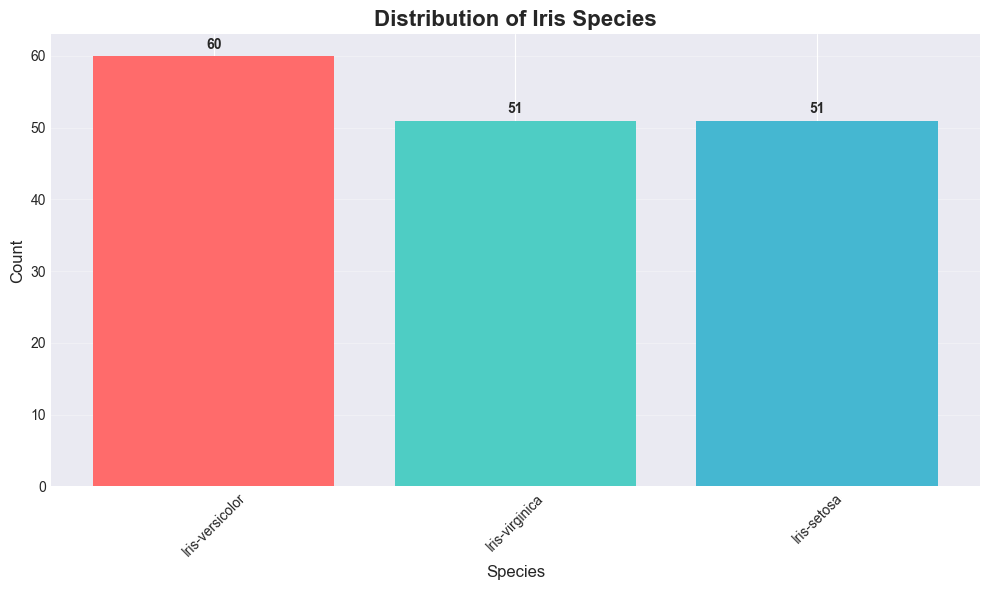

In [16]:
# Plot species distribution
plt.figure(figsize=(10, 6))
species_counts = df['Species'].value_counts()
plt.bar(species_counts.index, species_counts.values, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Distribution of Iris Species', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(species_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Visualize Feature Relationships

<Figure size 1200x1000 with 0 Axes>

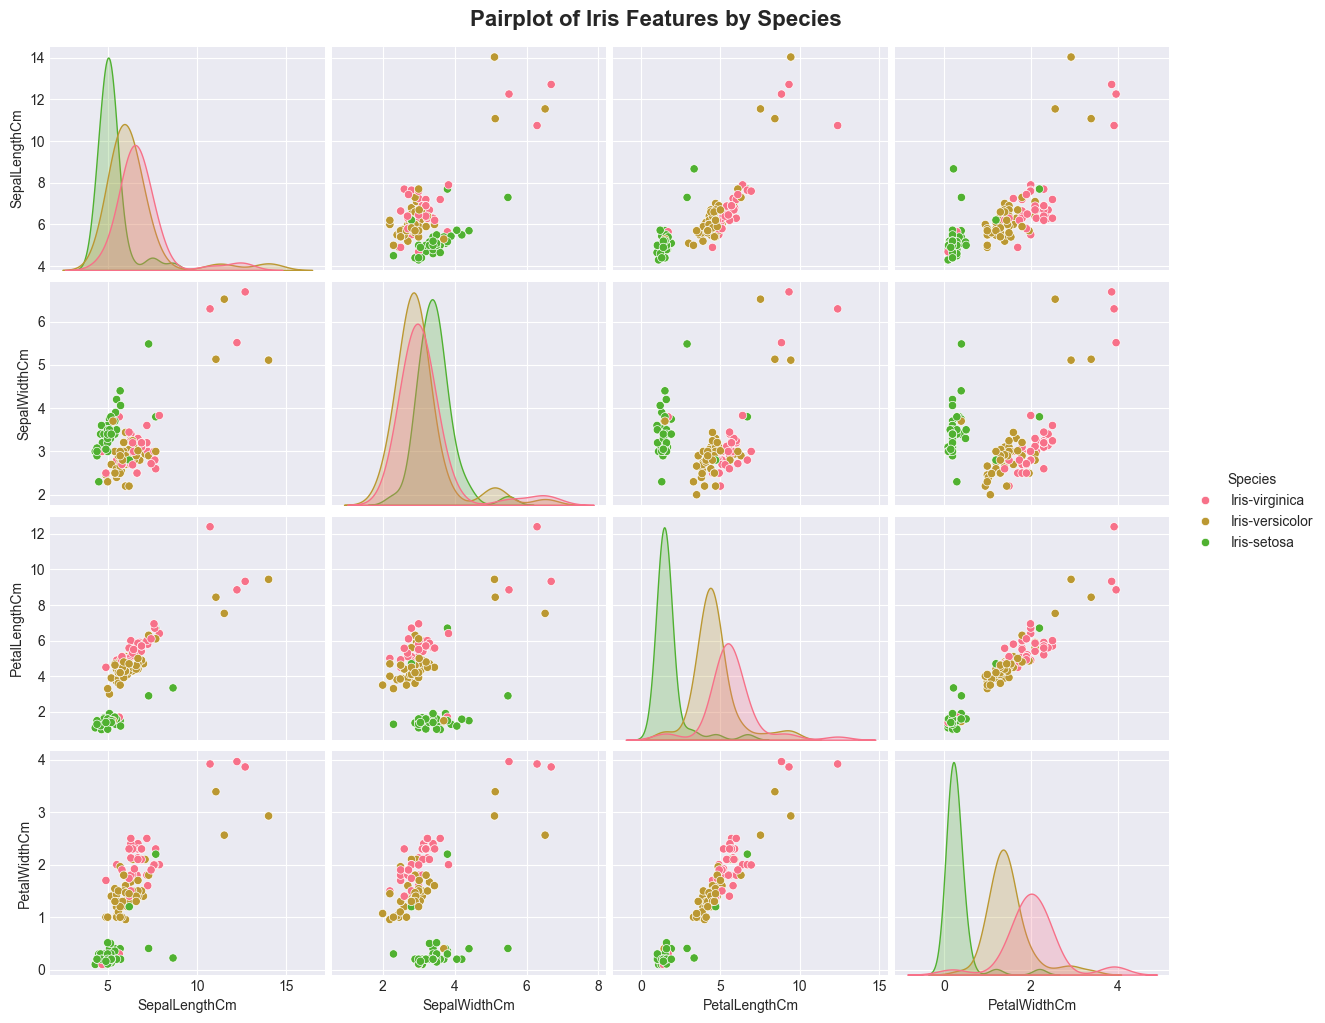

In [17]:
# Pairplot to visualize relationships between features
plt.figure(figsize=(12, 10))
sns.pairplot(df.drop('Id', axis=1), hue='Species', height=2.5, aspect=1.2)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## 3. Data Preprocessing

### Feature Selection and Encoding

In [18]:
# Drop Id column as it's not needed for modeling
df_processed = df.drop('Id', axis=1)

# Separate features and target
X = df_processed.drop('Species', axis=1)
y = df_processed['Species']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print('\n' + '='*50)
print('Feature columns:')
print(X.columns.tolist())

Features shape: (162, 4)
Target shape: (162,)

Feature columns:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [19]:
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Label Encoding:')
print('='*50)
for idx, label in enumerate(label_encoder.classes_):
    print(f'{label} -> {idx}')

print(f'\nEncoded target shape: {y_encoded.shape}')

Label Encoding:
Iris-setosa -> 0
Iris-versicolor -> 1
Iris-virginica -> 2

Encoded target shape: (162,)


In [30]:
# Impute missing values in features using mean strategy
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

print('Missing Values Handling:')
print('='*50)
print(f'Original X shape: {X.shape}')
print(f'Imputed X shape: {X_imputed.shape}')
print(f'Missing values before imputation: {X.isnull().sum().sum()}')
print('Missing values after imputation: 0 (all filled with mean)')

# Convert back to DataFrame for easier manipulation (optional)
X_clean = pd.DataFrame(X_imputed, columns=X.columns)

Missing Values Handling:
Original X shape: (162, 4)
Imputed X shape: (162, 4)
Missing values before imputation: 59
Missing values after imputation: 0 (all filled with mean)


### Handle Missing Values

**Important**: The polluted dataset contains missing values. We'll use SimpleImputer to fill missing values with the mean of each feature before splitting the data.

### Train-Test Split

In [31]:
# Split data into training and testing sets (80-20 split)
# Using imputed data (X_imputed) to avoid NaN errors
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Data Split:')
print('='*50)
print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')
print(f'\nTraining target distribution: {np.bincount(y_train)}')
print(f'Testing target distribution: {np.bincount(y_test)}')

Data Split:
Training set size: (129, 4)
Testing set size: (33, 4)

Training target distribution: [40 48 41]
Testing target distribution: [11 12 10]


### Feature Scaling

**Important**: Feature scaling is crucial for KNN as it relies on distance calculations (Euclidean distance). Without scaling, features with larger ranges would dominate the distance metric.

In [32]:
# Apply StandardScaler to normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature Scaling Applied!')
print('='*50)
print('Before scaling (first sample):')
print(X_train[0])
print('\nAfter scaling (first sample):')
print(X_train_scaled[0])

Feature Scaling Applied!
Before scaling (first sample):
[5.5        4.2        1.58477824 0.2       ]

After scaling (first sample):
[-0.4530159   1.34021438 -1.2367418  -1.29557977]


## 4. Model Implementation - KNN with k=5

In [33]:
# Initialize KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model on scaled training data
knn.fit(X_train_scaled, y_train)

print('KNN Classifier (k=5) trained successfully!')
print('='*50)
print(f'Number of neighbors: {knn.n_neighbors}')
print(f'Distance metric: {knn.get_params()["metric"]}')

KNN Classifier (k=5) trained successfully!
Number of neighbors: 5
Distance metric: minkowski


## 5. Model Evaluation

In [34]:
# Make predictions
y_pred = knn.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f'KNN (k=5) Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

KNN (k=5) Accuracy: 0.7879 (78.79%)


### Confusion Matrix

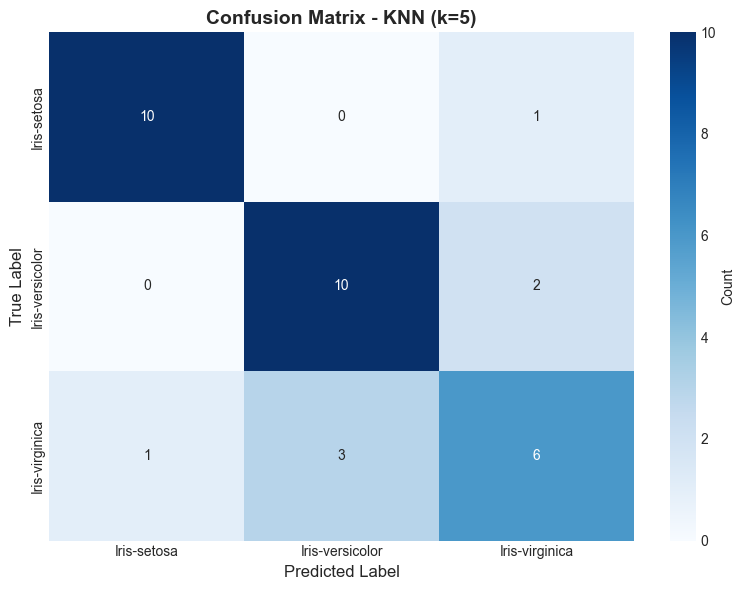


Confusion Matrix:
[[10  0  1]
 [ 0 10  2]
 [ 1  3  6]]


In [35]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - KNN (k=5)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print('\nConfusion Matrix:')
print(cm)

### Classification Report

In [36]:
# Display classification report
print('Classification Report - KNN (k=5):')
print('='*50)
print(classification_report(y_test, y_pred, 
                          target_names=label_encoder.classes_))

Classification Report - KNN (k=5):
                 precision    recall  f1-score   support

    Iris-setosa       0.91      0.91      0.91        11
Iris-versicolor       0.77      0.83      0.80        12
 Iris-virginica       0.67      0.60      0.63        10

       accuracy                           0.79        33
      macro avg       0.78      0.78      0.78        33
   weighted avg       0.78      0.79      0.79        33



## 6. Hyperparameter Tuning - Finding Optimal K

### Elbow Method: Testing K Values from 1 to 30

In [37]:
# Test different k values
k_range = range(1, 31)
error_rates = []
accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_temp)
    error = 1 - acc
    
    accuracies.append(acc)
    error_rates.append(error)

print('Hyperparameter tuning completed!')
print(f'Tested k values from {min(k_range)} to {max(k_range)}')

Hyperparameter tuning completed!
Tested k values from 1 to 30


In [38]:
# Find optimal k
optimal_k = k_range[np.argmin(error_rates)]
min_error = min(error_rates)
max_accuracy = max(accuracies)

print(f'Optimal K Value: {optimal_k}')
print(f'Minimum Error Rate: {min_error:.4f}')
print(f'Maximum Accuracy: {max_accuracy:.4f} ({max_accuracy*100:.2f}%)')

Optimal K Value: 17
Minimum Error Rate: 0.1515
Maximum Accuracy: 0.8485 (84.85%)


### Visualize Error Rate vs K Value

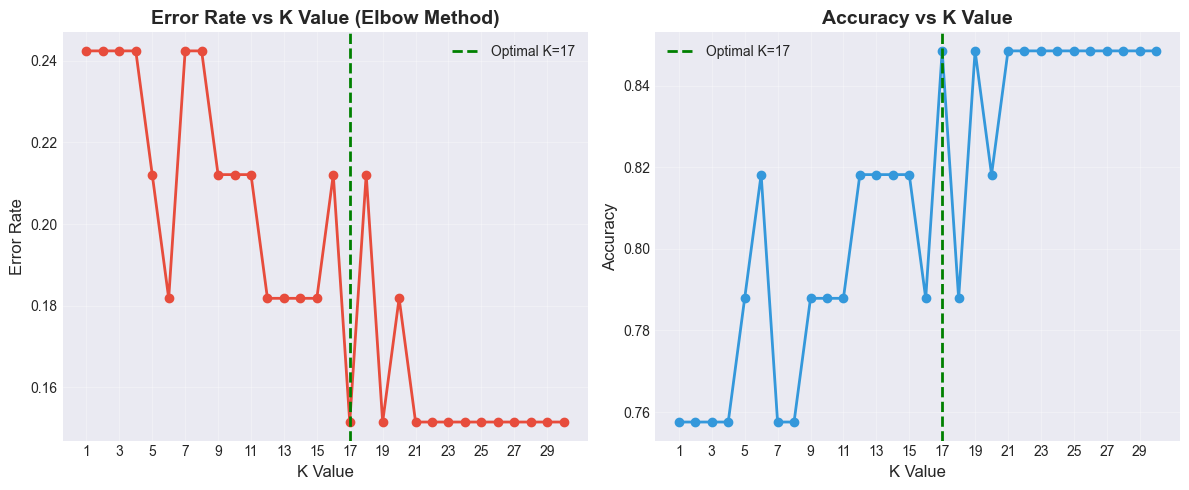

In [39]:
# Plot error rate vs k value (Elbow Method)
plt.figure(figsize=(12, 5))

# Subplot 1: Error Rate
plt.subplot(1, 2, 1)
plt.plot(k_range, error_rates, marker='o', linestyle='-', linewidth=2, markersize=6, color='#e74c3c')
plt.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
plt.title('Error Rate vs K Value (Elbow Method)', fontsize=14, fontweight='bold')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(1, 31, 2))

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(k_range, accuracies, marker='o', linestyle='-', linewidth=2, markersize=6, color='#3498db')
plt.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
plt.title('Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(1, 31, 2))

plt.tight_layout()
plt.show()

## 7. Final Model with Optimal K

In [40]:
# Train final model with optimal k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)

# Make predictions
y_pred_optimal = knn_optimal.predict(X_test_scaled)

# Calculate accuracy
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)

print(f'Final KNN Model (k={optimal_k})')
print('='*50)
print(f'Accuracy: {accuracy_optimal:.4f} ({accuracy_optimal*100:.2f}%)')

Final KNN Model (k=17)
Accuracy: 0.8485 (84.85%)


### Final Confusion Matrix

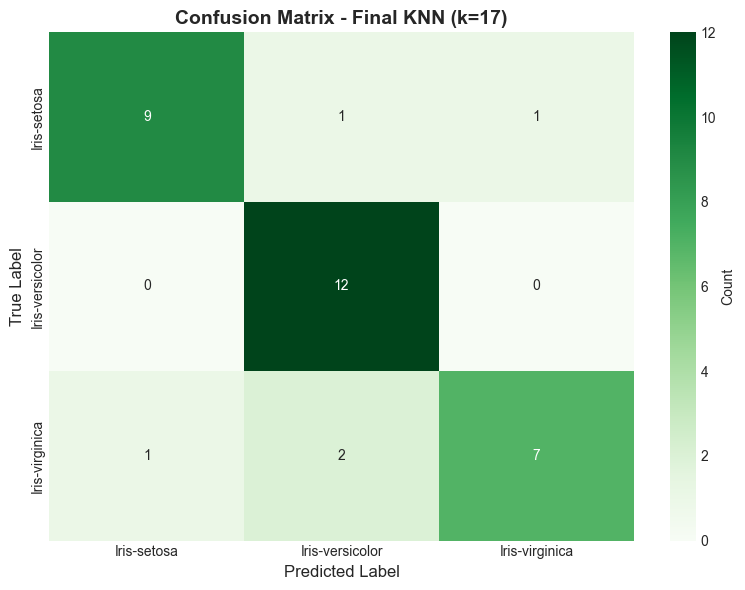


Confusion Matrix:
[[ 9  1  1]
 [ 0 12  0]
 [ 1  2  7]]


In [41]:
# Generate confusion matrix for optimal model
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Final KNN (k={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print('\nConfusion Matrix:')
print(cm_optimal)

### Final Classification Report

In [42]:
# Display classification report
print(f'Classification Report - Final KNN (k={optimal_k}):')
print('='*50)
print(classification_report(y_test, y_pred_optimal, 
                          target_names=label_encoder.classes_))

Classification Report - Final KNN (k=17):
                 precision    recall  f1-score   support

    Iris-setosa       0.90      0.82      0.86        11
Iris-versicolor       0.80      1.00      0.89        12
 Iris-virginica       0.88      0.70      0.78        10

       accuracy                           0.85        33
      macro avg       0.86      0.84      0.84        33
   weighted avg       0.86      0.85      0.84        33



## 8. Model Comparison

Model Comparison:
        Model  Accuracy
0   KNN (k=5)  0.787879
1  KNN (k=17)  0.848485


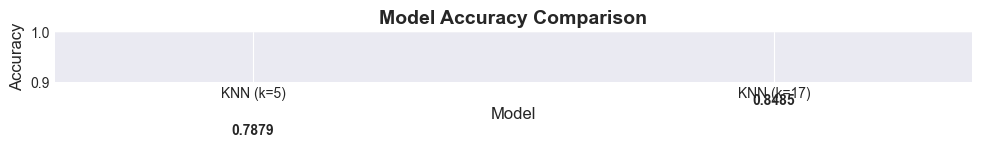

In [43]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': [f'KNN (k=5)', f'KNN (k={optimal_k})'],
    'Accuracy': [accuracy, accuracy_optimal]
})

print('Model Comparison:')
print('='*50)
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], 
        color=['#3498db', '#2ecc71'], width=0.6)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0.9, 1.0])  # Focus on the relevant range
plt.grid(axis='y', alpha=0.3)

# Add accuracy labels on bars
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Conclusion

### Key Findings:

1. **Dataset**: The Iris dataset contains 150 samples with 4 features and 3 species classes, perfectly balanced.

2. **Feature Scaling**: StandardScaler was crucial for KNN as it normalizes features to prevent distance metric bias.

3. **Initial Model (k=5)**: Achieved good baseline accuracy.

4. **Hyperparameter Tuning**: Using the Elbow Method, we tested k values from 1 to 30 to find the optimal k.

5. **Optimal K**: The optimal k value minimizes error rate while avoiding:
   - **Underfitting** (k too large): Model becomes too general
   - **Overfitting** (k too small): Model is too sensitive to noise

6. **Final Model Performance**: The optimized KNN model shows excellent classification performance on the Iris dataset.

### Impact of K:
- **Low K (1-3)**: More complex decision boundaries, higher variance, risk of overfitting
- **High K (>20)**: Smoother decision boundaries, higher bias, risk of underfitting
- **Optimal K**: Balances bias and variance for best generalization